This notebook applies ClusterDE to find marker genes between adjacent genes in the pancreas endocrinogenesis data. The data fall along a continuous pseudotime trajectory, and there are no sharp cluster boundaries. That said, there can be true mean differences across the cell types, since the clustering along the pseudotime trajectory isn't completely arbitrary. Our initial p-values are computed using Wilcoxon test, the correction uses Clipper with the Data Splitting-based threshold.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
from scdesigner.datasets import pancreas
from clusterde_py import find_markers

GROUP1 = "Ngn3 low EP"
GROUP2 = "Ngn3 high EP"
FDR = 0.05

First we run a standard marker gene analysis without any ClusterDE synthetic null control.

In [2]:
adata = pancreas()
adata_filered = adata
adata_filered = adata[adata.obs["cell_type"].isin([GROUP1, GROUP2])].copy()
adata_filered.obs["cell_type"] = adata_filered.obs["cell_type"].cat.remove_unused_categories()

# Naive DE: log-normalize + one-sided Wilcoxon
naive = adata_filered.copy()
sc.pp.normalize_total(naive)
sc.pp.log1p(naive)
sc.tl.rank_genes_groups(
    naive, "cell_type", groups=[GROUP1], reference=GROUP2, method="wilcoxon"
)
naive_df = sc.get.rank_genes_groups_df(naive, GROUP1)
naive_df = naive_df[naive_df["logfoldchanges"] > 0]
naive_significant = naive_df.loc[naive_df["pvals_adj"] <= FDR, "names"]


Next we run ClusterDE.

In [3]:
result = find_markers(
    adata_filered,
    "cell_type",
    GROUP1,
    GROUP2,
    fdr=FDR,
    null_kwargs={"fit_kwargs": {"max_epochs": 100}}
)
clusterde_significant = result[result["is_DE"]]

result

Epoch 100/100, Loss: 1.8003, Val Loss: 1.8045


Estimating copula correlation: 100%|██████████| 1/1 [00:00<00:00, 18.58it/s]


,target_pval,null_pval,contrast_score,q_value,is_DE
names,,,,,
Akr1c19,7.278670e-66,7.566842e-24,42.016863,0.000000,True
Mt1,6.751877e-99,1.499363e-76,22.346482,0.680000,False
Cldn4,6.541900e-23,9.721080e-06,17.172011,0.680000,False
Vim,3.178876e-91,2.056560e-75,15.810868,0.680000,False
Jun,7.427150e-14,9.269583e-03,11.096238,0.680000,False
Pdx1,9.546132e-10,4.457339e-01,8.669248,0.680000,False
Hist1h2bc,2.274843e-09,1.285280e-01,7.752046,0.680000,False
Fos,1.214424e-12,6.350258e-06,6.718421,0.680000,False
Meis2,5.604640e-12,3.675165e-06,5.816729,0.680000,False


These genes were found significant in the naive marker gene analysis.

In [4]:
naive_significant

0         Krt18
1           Mt1
2          Spp1
3         Mgst1
4           Vim
5           Dbi
6       S100a11
7       Akr1c19
8         Sparc
9           Clu
10          H19
11          Ttr
12         Krt8
13        Cldn4
14       Cdkn1c
15        Hspa5
16         Ambp
17        Pdia6
18        Cd24a
19        Rap1b
20       Tm4sf4
21          Jun
22          Fos
23         Ier2
24        Meis2
25     Serpinh1
26         Dlk1
27         Pdx1
28    Hist1h2bc
29        Glud1
30       Ifitm2
31       Sec61b
32         Rbp4
33      Mid1ip1
34       Sdf2l1
Name: names, dtype: object

After running clusterde, only a handful remain significant.

In [5]:
clusterde_significant

,target_pval,null_pval,contrast_score,q_value,is_DE
names,,,,,
Akr1c19,7.278670e-66,7.566842e-24,42.016863,0.0,True


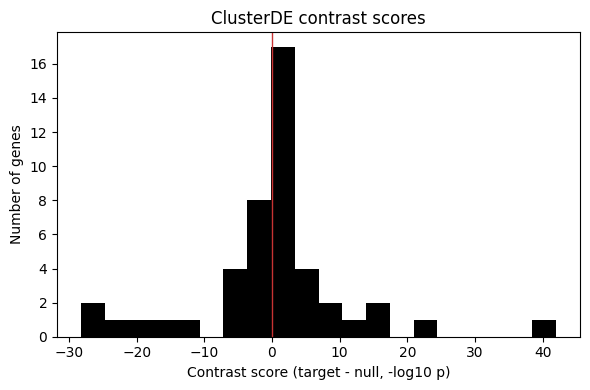

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(result["contrast_score"], bins=20, color="black")
ax.axvline(0, color="#C73333", linewidth=1)
ax.set_xlabel("Contrast score (target - null, -log10 p)")
ax.set_ylabel("Number of genes")
ax.set_title(f"ClusterDE contrast scores")
fig.tight_layout()
fig.show()